In [100]:
# 🔧 Configuración del notebook
import warnings
warnings.filterwarnings('ignore')

In [101]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import os


# --- Configura aquí la ruta según tu entorno ---
ARCHIVO = 'datos_procesados.csv'

# Intenta cargar desde distintas ubicaciones comunes
rutas = [
    ARCHIVO,                                          # directorio actual
    f'/content/{ARCHIVO}',                            # Colab raíz
    f'/content/drive/MyDrive/{ARCHIVO}',              # Google Drive
    f'../data/{ARCHIVO}',                             # carpeta data relativa
]

df = None
for ruta in rutas:
    if os.path.exists(ruta):
        df = pd.read_csv(ruta)
        print(f"✅ Archivo cargado desde: {ruta}")
        break

if df is None:
    raise FileNotFoundError(
        f"❌ No se encontró '{ARCHIVO}'. "
        "Sube el archivo al entorno o ajusta la ruta."
    )

✅ Archivo cargado desde: /content/drive/MyDrive/datos_procesados.csv


Verificamos si los clusters existen:

#Detectamos Outliers utilizando Isolation Forest

In [102]:
# ============================================
# 🌲 DETECCIÓN DE OUTLIERS - ISOLATION FOREST
# ============================================
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# --- 1. Preparamos los features  ---
# --- Se excluyen las columnas de cluster y POBREZA ---
cols_excluir = ['POBREZA']
feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                if col not in cols_excluir]

print(f"📌 Variables usadas para Isolation Forest: {feature_cols}")

X = df[feature_cols].copy()

# --- 2. Escalar No es obligatorio, pero mejora consistencia ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Aplicar Isolation Forest ---
iso_forest = IsolationForest(
    n_estimators=100,      # número de árboles
    contamination=0.1,    # % esperado de outliers
    random_state=42
)

df['outlier_iforest'] = iso_forest.fit_predict(X_scaled)
# Resultado: -1 = outlier, 1 = normal

df['outlier_score']   = iso_forest.decision_function(X_scaled)

# Convertir a etiqueta más legible
df['es_outlier'] = df['outlier_iforest'].map({-1: 'Outlier', 1: 'Normal'})

# --- 4. Resumen ---
n_outliers = (df['outlier_iforest'] == -1).sum()
n_total = len(df)
print(f"\n📊 Outliers detectados: {n_outliers} ({n_outliers/n_total*100:.1f}%)")
print(f"📊 Normales:            {n_total - n_outliers} ({(n_total-n_outliers)/n_total*100:.1f}%)")

📌 Variables usadas para Isolation Forest: ['PERCEPHO', 'P103', 'P104', 'P105A', 'EDUCACION_JEFE', 'DOMINIO', 'NUM_SERVICIOS', 'NUM_EQUIPOS', 'NUM_OCUPADOS', 'EDAD_JEFE', 'PCT_NINOS', 'HACINAMIENTO']

📊 Outliers detectados: 3277 (10.0%)
📊 Normales:            29487 (90.0%)


# **Distribución del score de la anomalía**

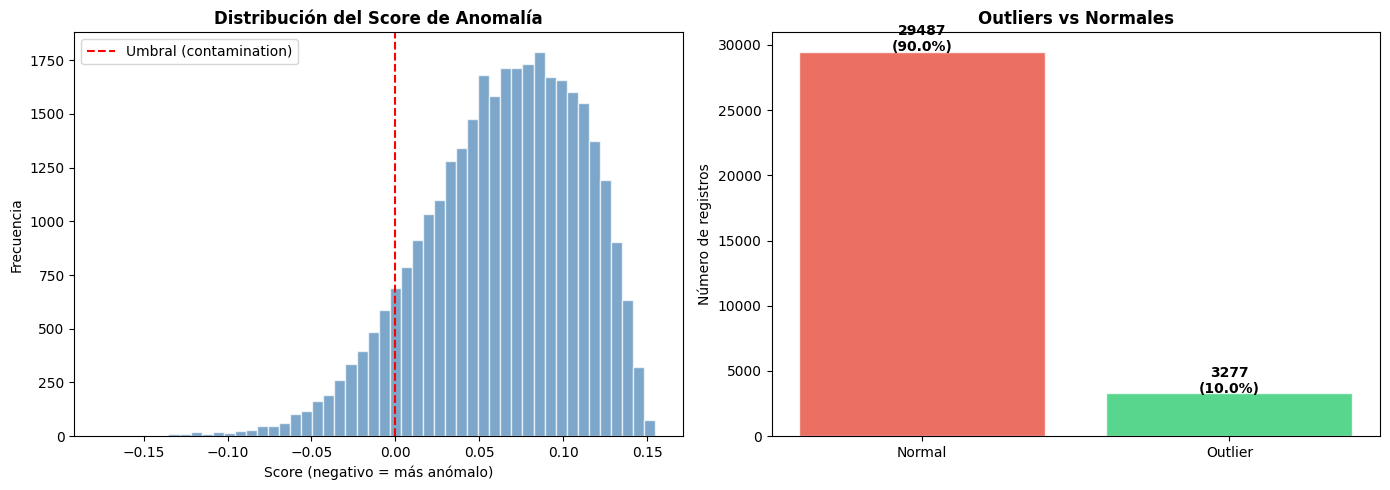

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del score
axes[0].hist(df['outlier_score'], bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Umbral (contamination)')
axes[0].set_title('Distribución del Score de Anomalía', fontweight='bold')
axes[0].set_xlabel('Score (negativo = más anómalo)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
# Conteo outlier vs normal
counts = df['es_outlier'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[1].bar(counts.index, counts.values, color=colors, alpha=0.8, edgecolor='white')
axes[1].set_title('Outliers vs Normales', fontweight='bold')
axes[1].set_ylabel('Número de registros')
for i, (label, val) in enumerate(counts.items()):
    axes[1].text(i, val + 50, f'{val}\n({val/n_total*100:.1f}%)',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# **Realizamos una comparación de perfiles**

Outliers vs Normales

In [104]:
print("\n📋 Perfil promedio: Outliers vs Normales")
perfil = df.groupby('es_outlier')[feature_cols].mean().round(3).T
perfil['Diferencia'] = (perfil['Outlier'] - perfil['Normal']).round(3)
perfil['Dirección'] = perfil['Diferencia'].apply(
    lambda x: '📈 Mayor en outlier' if x > 0 else '📉 Menor en outlier'
)
print(perfil)


📋 Perfil promedio: Outliers vs Normales
es_outlier      Normal  Outlier  Diferencia           Dirección
PERCEPHO         1.906    2.827       0.921  📈 Mayor en outlier
P103             4.785    3.766      -1.019  📉 Menor en outlier
P104             3.187    4.104       0.917  📈 Mayor en outlier
P105A            2.469    3.389       0.920  📈 Mayor en outlier
EDUCACION_JEFE   5.442    6.516       1.074  📈 Mayor en outlier
DOMINIO          4.872    4.783      -0.089  📉 Menor en outlier
NUM_SERVICIOS    8.000    8.000       0.000  📉 Menor en outlier
NUM_EQUIPOS      6.000    6.000       0.000  📉 Menor en outlier
NUM_OCUPADOS     1.594    2.312       0.718  📈 Mayor en outlier
EDAD_JEFE       54.458   52.225      -2.233  📉 Menor en outlier
PCT_NINOS        0.113    0.222       0.109  📈 Mayor en outlier
HACINAMIENTO     2.767    4.557       1.790  📈 Mayor en outlier


## **Contruimos el índice de precariedad**

In [105]:
mm = MinMaxScaler()

# P103, P104, P105A son binarias (1=tiene, 0=no tiene)
# Las invertimos: no tener servicio = más precario
df['p103_inv'] = 1 - df['P103']   # sin agua potable
df['p104_inv'] = 1 - df['P104']   # sin desagüe
df['p105a_inv'] = 1 - df['P105A'] # sin electricidad

# HACINAMIENTO: ya va en dirección correcta (más = peor)
df['hacinamiento_norm'] = mm.fit_transform(df[['HACINAMIENTO']])

# NUM_SERVICIOS y NUM_EQUIPOS: más = mejor, los invertimos
df['servicios_inv'] = 1 - mm.fit_transform(df[['NUM_SERVICIOS']])
df['equipos_inv']   = 1 - mm.fit_transform(df[['NUM_EQUIPOS']])

# Índice final: promedio de todos los componentes
# Rango [0,1]: 0 = ninguna precariedad, 1 = precariedad máxima
df['indice_precariedad'] = (
    df['p103_inv'] +
    df['p104_inv'] +
    df['p105a_inv'] +
    df['hacinamiento_norm']+
    df['servicios_inv'] +
    df['equipos_inv']

) / 6

print("📊 Índice de precariedad:")
print(df['indice_precariedad'].describe().round(3))

📊 Índice de precariedad:
count    32764.000
mean        -0.891
std          0.368
min         -2.615
25%         -1.126
50%         -0.826
75%         -0.647
max          0.374
Name: indice_precariedad, dtype: float64


# **Identificación de los casos paradójicos**

In [106]:
# Umbrales basados en percentiles
p75_proveedor      = df['PERCEPHO'].quantile(0.75)
p25_proveedor      = df['PERCEPHO'].quantile(0.25)
p75_precariedad  = df['indice_precariedad'].quantile(0.75)
p25_precariedad  = df['indice_precariedad'].quantile(0.25)

print(f"💰 PERCEPHO        — P25: {p25_proveedor:.0f}  | P75: {p75_proveedor:.0f}")
print(f"🏚️  Precariedad     — P25: {p25_precariedad:.3f} | P75: {p75_precariedad:.3f}")

# Tipo 1: padre y madre trabajan pero vive mal
mascara_t1 = (
    (df['PERCEPHO'] >= p75_proveedor) &
    (df['indice_precariedad'] >= p75_precariedad)
)

# Tipo 2: padre o madre pero vive bien
mascara_t2 = (
    (df['PERCEPHO'] <= p25_proveedor) &
    (df['indice_precariedad'] <= p25_precariedad)
)

df['outlier_paradojico'] = 'Normal'
df.loc[mascara_t1, 'outlier_paradojico'] = 'Ingreso alto + Precariedad alta'
df.loc[mascara_t2, 'outlier_paradojico'] = 'Ingreso bajo + Vida digna'

print("\n📋 Distribución:")
print(df['outlier_paradojico'].value_counts())

💰 PERCEPHO        — P25: 1  | P75: 2
🏚️  Precariedad     — P25: -1.126 | P75: -0.647

📋 Distribución:
outlier_paradojico
Normal                             24226
Ingreso alto + Precariedad alta     5592
Ingreso bajo + Vida digna           2946
Name: count, dtype: int64


# **Perfil promedio de cada tipo**

In [107]:
vars_perfil = [
    'PERCEPHO', 'indice_precariedad',
    'HACINAMIENTO', 'P103', 'P104', 'P105A',
    'NUM_SERVICIOS', 'NUM_EQUIPOS', 'POBREZA'
]

print("\n📋 Perfil promedio por tipo:")
print(
    df.groupby('outlier_paradojico')[vars_perfil]
    .mean().round(3)
)


📋 Perfil promedio por tipo:
                                 PERCEPHO  indice_precariedad  HACINAMIENTO  \
outlier_paradojico                                                            
Ingreso alto + Precariedad alta     2.399              -0.488         3.469   
Ingreso bajo + Vida digna           0.997              -1.349         1.925   
Normal                              2.027              -0.928         2.949   

                                  P103   P104  P105A  NUM_SERVICIOS  \
outlier_paradojico                                                    
Ingreso alto + Precariedad alta  3.737  2.626  1.774            8.0   
Ingreso bajo + Vida digna        5.125  3.375  4.704            8.0   
Normal                           4.848  3.417  2.482            8.0   

                                 NUM_EQUIPOS  POBREZA  
outlier_paradojico                                     
Ingreso alto + Precariedad alta          6.0    2.816  
Ingreso bajo + Vida digna                6.0    2.8

# 📊 **VISUALIZACIÓN DE OUTLIERS EN PCA**

In [108]:
from sklearn.decomposition import PCA

# --- 1. Aplicar PCA sobre las features escaladas ---
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(X_scaled)

df['PC1'] = componentes[:, 0]
df['PC2'] = componentes[:, 1]

varianza = pca.explained_variance_ratio_
print(f"📐 Varianza explicada — PC1: {varianza[0]*100:.1f}% | PC2: {varianza[1]*100:.1f}%")
print(f"   Total: {sum(varianza)*100:.1f}%")

📐 Varianza explicada — PC1: 24.1% | PC2: 16.6%
   Total: 40.8%


# **Gráfico 1 — Isolation Forest**

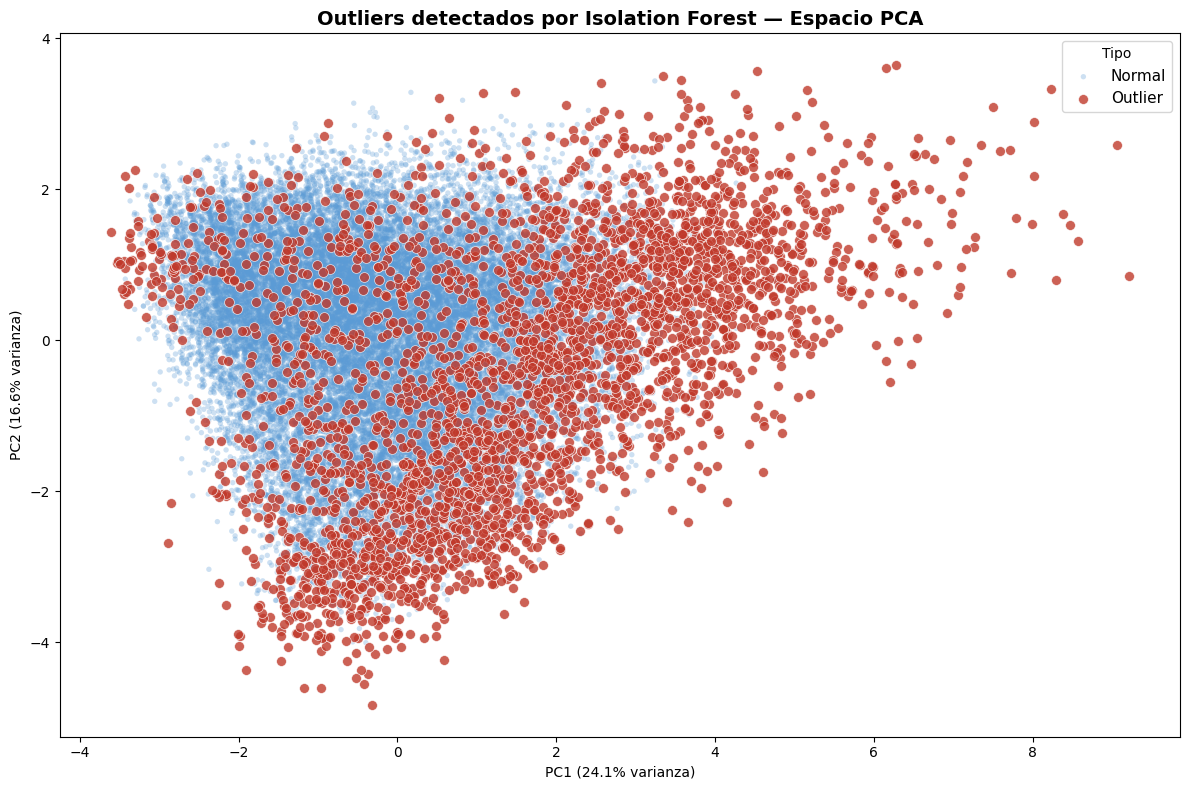

In [109]:
fig, ax = plt.subplots(figsize=(12, 8))

colores  = {'Normal': '#5B9BD5', 'Outlier': '#C0392B'}
tamaños  = {'Normal': 15,        'Outlier': 50}
alphas   = {'Normal': 0.3,       'Outlier': 0.8}

for tipo, grupo in df.groupby('es_outlier'):
    ax.scatter(
        grupo['PC1'], grupo['PC2'],
        c=colores[tipo], s=tamaños[tipo],
        alpha=alphas[tipo], label=tipo,
        edgecolors='white' if tipo == 'Outlier' else 'none',
        linewidths=0.5, zorder=3 if tipo == 'Outlier' else 1
    )

ax.set_title('Outliers detectados por Isolation Forest — Espacio PCA', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({varianza[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({varianza[1]*100:.1f}% varianza)')
ax.legend(title='Tipo', fontsize=11)
plt.tight_layout()
plt.show()

# **Gráfico 2 — Outliers paradójicos**

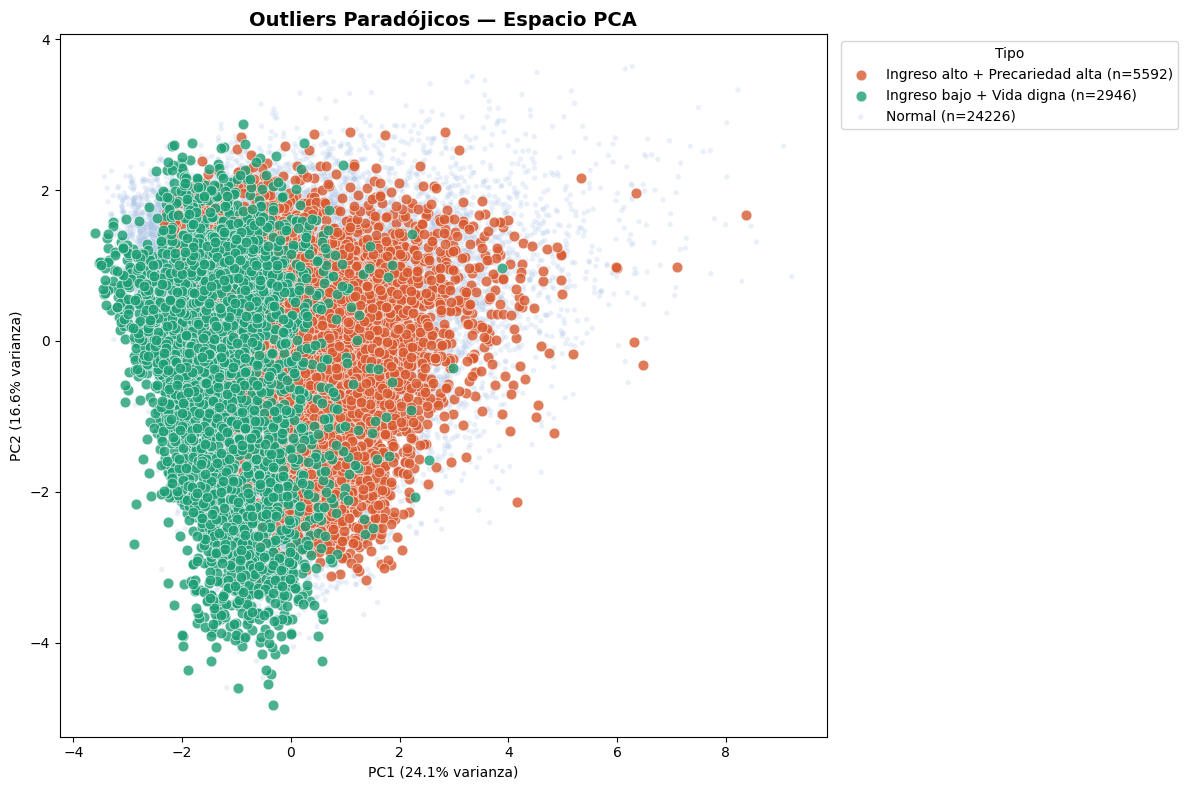

In [110]:
fig, ax = plt.subplots(figsize=(12, 8))

colores_p = {
    'Normal':                        '#AEC6E8',
    'Ingreso alto + Precariedad alta': '#D85A30',
    'Ingreso bajo + Vida digna':       '#1D9E75'
}
tamaños_p = {
    'Normal': 15,
    'Ingreso alto + Precariedad alta': 60,
    'Ingreso bajo + Vida digna': 60
}

for tipo, grupo in df.groupby('outlier_paradojico'):
    ax.scatter(
        grupo['PC1'], grupo['PC2'],
        c=colores_p[tipo], s=tamaños_p[tipo],
        alpha=0.8 if tipo != 'Normal' else 0.25,
        label=f"{tipo} (n={len(grupo)})",
        edgecolors='white' if tipo != 'Normal' else 'none',
        linewidths=0.5,
        zorder=3 if tipo != 'Normal' else 1
    )

ax.set_title('Outliers Paradójicos — Espacio PCA', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({varianza[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({varianza[1]*100:.1f}% varianza)')
ax.legend(title='Tipo', fontsize=10, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# **Gráfico 3 — Los tres tipos juntos**

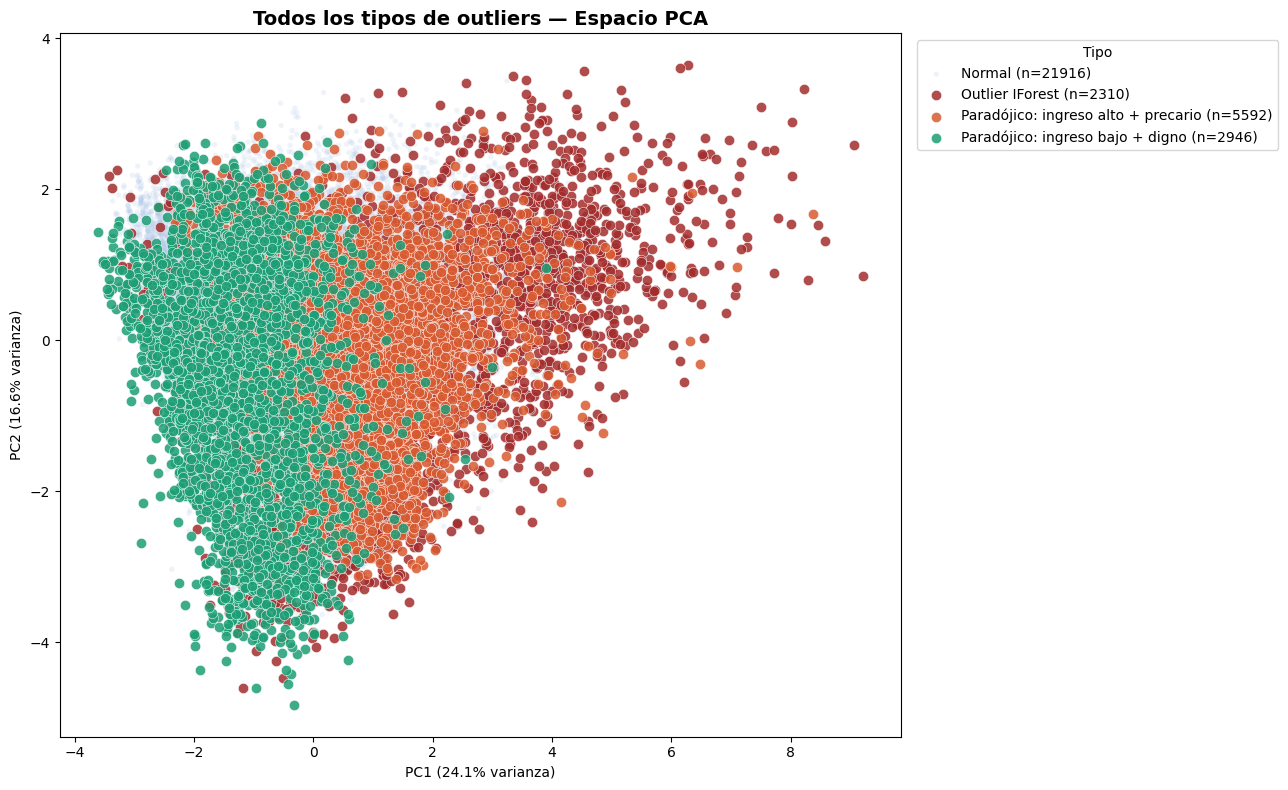

In [111]:
# Creamos columna combinada para ver todo de una vez
def clasificar(row):
    if row['outlier_paradojico'] == 'Ingreso alto + Precariedad alta':
        return 'Paradójico: ingreso alto + precario'
    elif row['outlier_paradojico'] == 'Ingreso bajo + Vida digna':
        return 'Paradójico: ingreso bajo + digno'
    elif row['es_outlier'] == 'Outlier':
        return 'Outlier IForest'
    return 'Normal'

df['tipo_final'] = df.apply(clasificar, axis=1)

colores_f = {
    'Normal':                             '#AEC6E8',
    'Outlier IForest':                    '#A32D2D',
    'Paradójico: ingreso alto + precario': '#D85A30',
    'Paradójico: ingreso bajo + digno':    '#1D9E75'
}

fig, ax = plt.subplots(figsize=(13, 8))
orden = ['Normal', 'Outlier IForest',
         'Paradójico: ingreso alto + precario',
         'Paradójico: ingreso bajo + digno']

for tipo in orden:
    grupo = df[df['tipo_final'] == tipo]
    ax.scatter(
        grupo['PC1'], grupo['PC2'],
        c=colores_f[tipo],
        s=15 if tipo == 'Normal' else 55,
        alpha=0.2 if tipo == 'Normal' else 0.85,
        label=f"{tipo} (n={len(grupo)})",
        edgecolors='white' if tipo != 'Normal' else 'none',
        linewidths=0.4,
        zorder=1 if tipo == 'Normal' else 3
    )

ax.set_title('Todos los tipos de outliers — Espacio PCA', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({varianza[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({varianza[1]*100:.1f}% varianza)')
ax.legend(title='Tipo', fontsize=10, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


# **✅ FASE 5: VALIDACIÓN CON POBREZA**

In [112]:
print("📋 Distribución de POBREZA:")
print(df['POBREZA'].value_counts().sort_index())
print(f"\nValores únicos: {sorted(df['POBREZA'].unique())}")

📋 Distribución de POBREZA:
POBREZA
1     1161
2     4792
3    26811
Name: count, dtype: int64

Valores únicos: [np.int64(1), np.int64(2), np.int64(3)]


## **Validación 1 — Isolation Forest vs POBREZA**

In [113]:
print("\n📊 Distribución de POBREZA según Isolation Forest:")
tabla_if = pd.crosstab(
    df['es_outlier'],
    df['POBREZA'],
    margins=True,
    normalize='index'  # porcentajes por fila
).round(3) * 100

print(tabla_if)


📊 Distribución de POBREZA según Isolation Forest:
POBREZA       1     2     3
es_outlier                 
Normal      3.5  14.4  82.1
Outlier     3.8  16.4  79.8
All         3.5  14.6  81.8


# **Validación 2 — Paradójicos vs POBREZA**

In [114]:
print("\n📊 Distribución de POBREZA según tipo paradójico:")
tabla_p = pd.crosstab(
    df['outlier_paradojico'],
    df['POBREZA'],
    margins=True,
    normalize='index'
).round(3) * 100

print(tabla_p)


📊 Distribución de POBREZA según tipo paradójico:
POBREZA                            1     2     3
outlier_paradojico                              
Ingreso alto + Precariedad alta  2.6  13.2  84.2
Ingreso bajo + Vida digna        3.0  11.9  85.0
Normal                           3.8  15.3  80.9
All                              3.5  14.6  81.8


# **Validación 3 — Visualización en PCA coloreado por POBREZA**

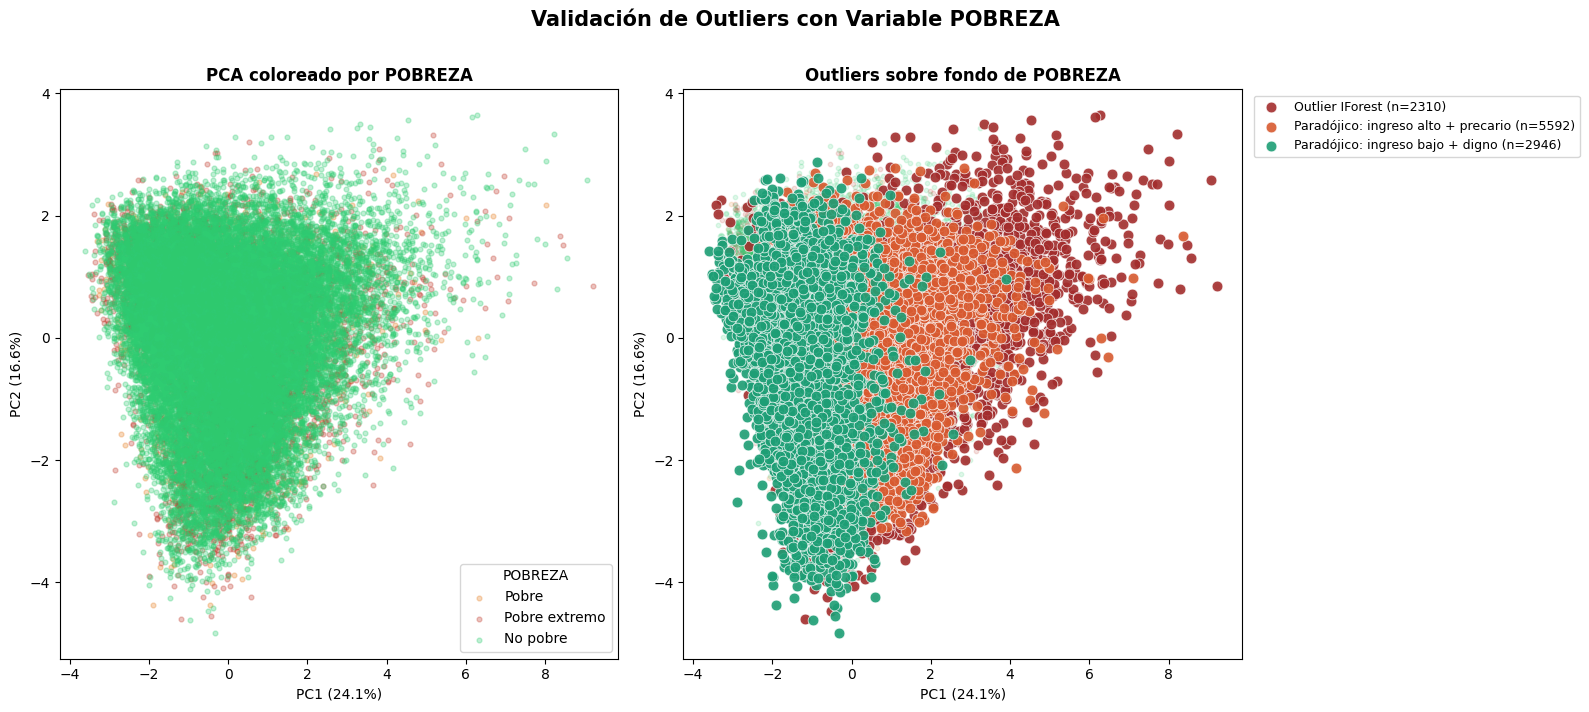

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

etiquetas_pobreza = {1: 'Pobre', 2: 'Pobre extremo', 3: 'No pobre'}
colores_pobreza   = {1: '#E67E22',  2: '#C0392B', 3: '#2ECC71'}

df['pobreza_label'] = df['POBREZA'].map(etiquetas_pobreza)

# --- Panel izquierdo: PCA coloreado por POBREZA ---
for val, grupo in df.groupby('POBREZA'):
    axes[0].scatter(
        grupo['PC1'], grupo['PC2'],
        c=colores_pobreza[val],
        s=12, alpha=0.3,
        label=etiquetas_pobreza[val]
    )

axes[0].set_title('PCA coloreado por POBREZA', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({varianza[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({varianza[1]*100:.1f}%)')
axes[0].legend(title='POBREZA', fontsize=10)

# --- Panel derecho: outliers sobre fondo de POBREZA ---
# Fondo: todos los hogares coloreados por POBREZA (tenue)
for val, grupo in df.groupby('POBREZA'):
    axes[1].scatter(
        grupo['PC1'], grupo['PC2'],
        c=colores_pobreza[val],
        s=10, alpha=0.15, zorder=1
    )

# Encima: solo los outliers (IForest + paradójicos)
colores_tipos = {
    'Outlier IForest':                     '#A32D2D',
    'Paradójico: ingreso alto + precario': '#D85A30',
    'Paradójico: ingreso bajo + digno':    '#1D9E75'
}

for tipo, color in colores_tipos.items():
    grupo = df[df['tipo_final'] == tipo]
    if len(grupo) > 0:
        axes[1].scatter(
            grupo['PC1'], grupo['PC2'],
            c=color, s=60, alpha=0.9,
            label=f"{tipo} (n={len(grupo)})",
            edgecolors='white', linewidths=0.5,
            zorder=3
        )

axes[1].set_title('Outliers sobre fondo de POBREZA', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({varianza[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({varianza[1]*100:.1f}%)')
axes[1].legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('Validación de Outliers con Variable POBREZA', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# **RESUMEN FINAL DE VALIDACIÓN**

In [116]:
print("\n" + "="*60)
print("📋 RESUMEN FINAL")
print("="*60)

grupos = {
    'Outlier IForest':                      df['es_outlier'] == 'Outlier',
    'Paradójico: ingreso alto + precario':  df['outlier_paradojico'] == 'Ingreso alto + Precariedad alta',
    'Paradójico: ingreso bajo + digno':     df['outlier_paradojico'] == 'Ingreso bajo + Vida digna',
    'Normal':                               df['tipo_final'] == 'Normal'
}

for nombre, mascara in grupos.items():
    sub = df[mascara]
    dist = sub['POBREZA'].value_counts(normalize=True).sort_index() * 100
    print(f"\n  {nombre} (n={mascara.sum()}):")
    for val, pct in dist.items():
        print(f"    POBREZA={val} ({etiquetas_pobreza[val]}): {pct:.1f}%")


📋 RESUMEN FINAL

  Outlier IForest (n=3277):
    POBREZA=1 (Pobre): 3.8%
    POBREZA=2 (Pobre extremo): 16.4%
    POBREZA=3 (No pobre): 79.8%

  Paradójico: ingreso alto + precario (n=5592):
    POBREZA=1 (Pobre): 2.6%
    POBREZA=2 (Pobre extremo): 13.2%
    POBREZA=3 (No pobre): 84.2%

  Paradójico: ingreso bajo + digno (n=2946):
    POBREZA=1 (Pobre): 3.0%
    POBREZA=2 (Pobre extremo): 11.9%
    POBREZA=3 (No pobre): 85.0%

  Normal (n=21916):
    POBREZA=1 (Pobre): 3.8%
    POBREZA=2 (Pobre extremo): 15.2%
    POBREZA=3 (No pobre): 81.1%


In [117]:
print(df['POBREZA'].value_counts().sort_index())

POBREZA
1     1161
2     4792
3    26811
Name: count, dtype: int64


In [118]:
print(df['es_outlier'].value_counts())
print(df['outlier_paradojico'].value_counts())

es_outlier
Normal     29487
Outlier     3277
Name: count, dtype: int64
outlier_paradojico
Normal                             24226
Ingreso alto + Precariedad alta     5592
Ingreso bajo + Vida digna           2946
Name: count, dtype: int64


In [119]:
print(pd.crosstab(df['es_outlier'], df['POBREZA'], normalize='index').round(3) * 100)
print(pd.crosstab(df['outlier_paradojico'], df['POBREZA'], normalize='index').round(3) * 100)

POBREZA       1     2     3
es_outlier                 
Normal      3.5  14.4  82.1
Outlier     3.8  16.4  79.8
POBREZA                            1     2     3
outlier_paradojico                              
Ingreso alto + Precariedad alta  2.6  13.2  84.2
Ingreso bajo + Vida digna        3.0  11.9  85.0
Normal                           3.8  15.3  80.9


In [120]:
vars_perfil = ['PERCEPHO', 'indice_precariedad', 'HACINAMIENTO', 'P103', 'P104', 'P105A', 'NUM_SERVICIOS', 'NUM_EQUIPOS', 'POBREZA']
print(df.groupby('outlier_paradojico')[vars_perfil].mean().round(3))

                                 PERCEPHO  indice_precariedad  HACINAMIENTO  \
outlier_paradojico                                                            
Ingreso alto + Precariedad alta     2.399              -0.488         3.469   
Ingreso bajo + Vida digna           0.997              -1.349         1.925   
Normal                              2.027              -0.928         2.949   

                                  P103   P104  P105A  NUM_SERVICIOS  \
outlier_paradojico                                                    
Ingreso alto + Precariedad alta  3.737  2.626  1.774            8.0   
Ingreso bajo + Vida digna        5.125  3.375  4.704            8.0   
Normal                           4.848  3.417  2.482            8.0   

                                 NUM_EQUIPOS  POBREZA  
outlier_paradojico                                     
Ingreso alto + Precariedad alta          6.0    2.816  
Ingreso bajo + Vida digna                6.0    2.820  
Normal                  